# Notebook 3 — Class Balancing: Strategy 3 (3:1 Random Undersampling)

---

### Overview

This notebook trains CVAF-SwinB using **Strategy 3 — 3:1 random undersampling**
as part of a four-strategy class balancing experiment. The benign training
patients are randomly reduced to three times the malignant count, producing
a 3:1 training set. No loss weighting is applied (pos_weight=1.0) so that
the resampling strategy alone addresses the class imbalance.

Compared to Strategy 2 (1:1 undersampling), Strategy 3 retains more benign
training diversity — 1,074 benign patients instead of 358 — while still
reducing the 9:1 natural imbalance. This allows a direct comparison of
how much benign diversity affects model performance.

This notebook contributes to answering **Research Question 3 (RQ3)**:

> *"Which class balancing strategy produces the highest AUC-ROC when
> fine-tuning a large pre-trained Vision Transformer on a severely
> imbalanced mammography dataset?"*

---

### Research context

**Thesis:** Enhance Vision Transformer based Breast Cancer Mammography Classification  
**Author:** Nirjana Shrestha — Student ID: MIT236388  
**Supervisors:** Prof. Adel Al-Jumaily · Dr Mohammad Dabbagh  
**Institution:** Melbourne Institute of Technology, Sydney, Australia  

---

### What 3:1 undersampling does

Random undersampling reduces the benign class to three times the malignant
count. Using seed=42:

$$N_{\text{benign}}^{(3:1)} = \min(N_{\text{benign}},\ 3 \times N_{\text{malignant}}) = \min(3207,\ 3 \times 358) = 1074$$

- All **358 malignant** training patients are kept
- **1,074 benign** patients are randomly sampled from the 3,207 available
- **2,133 benign** patients are discarded from training
- Training set reduces from **3,565 → 1,432 patients**
- Validation and test sets are **unchanged** — natural 9:1 distribution

---

### Strategy comparison

| Strategy | Notebook | pos_weight | Resampling | Train patients | Ratio |
|---|---|---|---|---|---|
| Strategy 1 — Loss weighting | NB1 | 3.0 | None | 3,565 | 9:1 |
| Strategy 2 — 1:1 Undersample | NB2 | 1.0 | Benign → 358 | 716 | 1:1 |
| **Strategy 3 — 3:1 Undersample** | **NB3 (this)** | **1.0** | **Benign → 1,074** | **1,432** | **3:1** |
| Strategy 4 — 3:1 Oversample | NB4 | 1.0 | Malignant → 1,069 | 4,276 | 3:1 |

---

### Dataset splits

| Split | Patients | Benign | Malignant | Ratio | Note |
|---|---|---|---|---|---|
| Train (after resampling) | 1,432 | 1,074 | 358 | **3:1** | Resampled |
| Validation | 764 | 687 | 77 | 9:1 | Unchanged |
| Test | 764 | 687 | 77 | 9:1 | Unchanged |

---

### Training settings

| Setting | Value | Note |
|---|---|---|
| pos_weight | 1.0 | No extra loss weighting |
| batch_size | 4 | Single GPU OOM fix |
| grad_accum | 8 | Effective batch size = 32 |
| patience | 10 | Early stopping on val AUC |
| seed | 42 | Identical split to all notebooks |

---

### Notebook structure

| Section | Content |
|---|---|
| A | Environment setup |
| B | Code file loading |
| C | Model training — Strategy 3 (3:1 undersample) |
| D | Results analysis and comparison |
| E | Visualisation graphs |
| F | Save outputs |

**Expected runtime: approximately 2 hours on Tesla T4.**

## A. Environment Setup

Install required libraries and verify GPU availability.
- `timm==1.0.3` — provides the Swin Transformer Base pretrained checkpoint
- `scikit-learn` — provides AUC-ROC, F1, sensitivity, specificity metrics

In [1]:
!pip install -q timm==1.0.3 scikit-learn

import torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.8 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires 

## B. Load Code Files

Three files are required for this experiment:
- `model.py` — CVAF-SwinB architecture, **unchanged** from Notebook 1
- `train.py` — Training loop, **unchanged** from Notebook 1
- `dataset_undersample_3to1.py` — Modified dataset pipeline that applies
  3:1 random undersampling to the training split only

`dataset_undersample_3to1.py` is renamed to `dataset.py` at load time.
The undersampling function uses:

$$N_{\text{benign}}^{(3:1)} = \min(N_{\text{benign}},\ 3 \times N_{\text{malignant}})$$

Benign patients are randomly sampled without replacement using seed=42,
ensuring the same patients are selected on every run for reproducibility.

In [2]:
import shutil, os, sys

SRC = "/kaggle/input/datasets/nirjanashrestha/undersampling3-1"
DST = "/kaggle/working/src"
os.makedirs(DST, exist_ok=True)

for f in ["model.py", "train.py"]:
    src = f"{SRC}/{f}"
    dst = f"{DST}/{f}"
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Copied {f}")
    else:
        print(f"MISSING — {f}")

undersample_src = f"{SRC}/dataset_undersample_3to1.py"
if os.path.exists(undersample_src):
    shutil.copy(undersample_src, f"{DST}/dataset.py")
    print("Copied dataset_undersample_3to1.py → dataset.py")
else:
    print("MISSING — dataset_undersample_3to1.py")

sys.path.insert(0, DST)
print("\nDone — all files ready")

Copied model.py
Copied train.py
Copied dataset_undersample_3to1.py → dataset.py

Done — all files ready


## C. Training — Strategy 3 (3:1 Random Undersampling)

Trains CVAF-SwinB on a 3:1 undersampled training set. The undersampling
is applied inside `dataset.py` — model and training loop are unchanged.

**Comparison with Strategy 2:**
Strategy 3 retains 1,074 benign patients vs 358 in Strategy 2 — three
times more benign diversity. This should reduce the overfitting observed
in Strategy 2 and produce a higher test AUC, while still underperforming
Strategy 1 which retains all 3,207 benign patients.

**What to expect:**
- Training set is 2× larger than Strategy 2 (1,432 vs 716 patients)
- Each epoch will take approximately 2× longer than Strategy 2
- Less overfitting than Strategy 2 — smaller train-val AUC gap expected
- Optimal threshold should be lower than Strategy 2 (0.90) but likely
  higher than Strategy 1 (0.09) as calibration is still affected

In [3]:
import argparse, gc, sys, os, torch

gc.collect()
torch.cuda.empty_cache()
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

for mod in ['train', 'model', 'dataset']:
    if mod in sys.modules:
        del sys.modules[mod]

from train import train

cfg = argparse.Namespace(
    cbis_root       = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset",
    vindr_root      = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    vindr_images    = "/kaggle/input/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png/images_png",
    vindr_labels    = "/kaggle/input/datasets/nirjanashrestha/vindr-annotations",
    save_dir        = "/kaggle/working/checkpoints_strategy3",
    img_size        = 224,
    batch_size      = 4,        # reduced from 8 — single GPU OOM fix
    grad_accum      = 8,        # effective batch size = 32
    num_workers     = 2,
    seed            = 42,
    epochs          = 100,
    patience        = 10,
    lr              = 1e-4,
    weight_decay    = 1e-2,
    pos_weight      = 1.0,      # no extra weighting — resampling handles imbalance
    label_smoothing = 0.0,
    wandb           = False,
)

print("=" * 65)
print("  NOTEBOOK 3 — STRATEGY 3: 3:1 RANDOM UNDERSAMPLING")
print("  pos_weight = 1.0  |  Training set = 1,432 patients")
print("  Benign = 1,074  |  Malignant = 358  |  Ratio = 3:1")
print("  batch_size=4  grad_accum=8  effective_batch=32")
print("=" * 65)

test_auc = train(cfg)
print(f"\n  Strategy 3 test AUC = {test_auc:.4f}")

  NOTEBOOK 3 — STRATEGY 3: 3:1 RANDOM UNDERSAMPLING
  pos_weight = 1.0  |  Training set = 1,432 patients
  Benign = 1,074  |  Malignant = 358  |  Ratio = 3:1
  batch_size=4  grad_accum=8  effective_batch=32
Device     : cuda
Epochs     : 100  |  patience=10
pos_weight : 1.0

Building dataloaders ...
[CBIS-DDSM] Loaded mass_case_description_train_set.csv  (1318 rows)
[CBIS-DDSM] Loaded mass_case_description_test_set.csv  (378 rows)
[CBIS-DDSM] Loaded calc_case_description_train_set.csv  (1546 rows)
[CBIS-DDSM] Loaded calc_case_description_test_set.csv  (326 rows)
[CBIS-DDSM] Combined: 3568 rows
[CBIS-DDSM] Indexing JPEG images ...
[CBIS-DDSM] Indexed 6,774 JPEG files
[CBIS-DDSM] Full mammogram series: 2857
[CBIS-DDSM] Full mammogram images indexed: 2857
[CBIS-DDSM] Rows with resolved paths: 3286
[CBIS-DDSM] Complete 4-view cases: 94  Benign=63  Malignant=31
[VinDr-Mammo] Loaded breast-level_annotations.csv  (20,000 rows)
[VinDr-Mammo] After BI-RADS filter: 20,000 rows  Benign=19012  Mal

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Using 2 GPUs
Model params: 192.2M

Scheduler: 220 warmup / 4400 total steps

---------------------------------------------------------------------------------------
 Epoch |  Tr Loss   Tr AUC  Tr BAcc |  Val Loss  Val AUC Val BAcc |         LR |   Time
---------------------------------------------------------------------------------------
     1 |   0.5829   0.5220   0.5009 |    0.3396   0.6468   0.5000 |   2.00e-05 | 226.8s
         New best val AUC = 0.6468  (saved)
     2 |   0.5447   0.6156   0.5335 |    0.3881   0.6411   0.5952 |   4.00e-05 | 198.9s
     3 |   0.5322   0.6318   0.5745 |    0.3861   0.6725   0.6153 |   6.00e-05 | 197.6s
         New best val AUC = 0.6725  (saved)
     4 |   0.5233   0.6610   0.5736 |    0.3954   0.7249   0.6146 |   8.00e-05 | 199.3s
         New best val AUC = 0.7249  (saved)
     5 |   0.5411   0.6407   0.5903 |    0.3293   0.7169   0.6247 |   1.00e-04 | 197.8s
     6 |   0.5320   0.6667   0.5861 |    0.2922   0.7403   0.6103 |   1.00e-04 | 199.7s

## D. Results Analysis

Loads the saved test results and prints a complete metrics table at both
the default threshold (0.50) and the optimal threshold.

Results are compared against:
- **Strategy 1** (pos_weight=3.0, 3,565 patients) — AUC = 0.7518
- **Strategy 2** (1:1 undersample, 716 patients) — AUC = 0.6940

Strategy 3 is expected to outperform Strategy 2 due to greater benign
training diversity (1,074 vs 358 benign patients), while still expected
to underperform Strategy 1 which retains the full 3,207 benign patients.

In [5]:
import json

with open('/kaggle/working/checkpoints_strategy3/test_results.json') as f:
    r = json.load(f)

d = r['default_threshold']
o = r['selected_threshold']

def fmt(val):
    try:
        return f'{float(val):.4f}'
    except:
        return 'N/A'

print("=" * 65)
print("  STRATEGY 3 — 3:1 UNDERSAMPLE — COMPLETE RESULTS")
print("=" * 65)
print(f"  Training set     : 1,432 patients (1,074 benign / 358 malignant)")
print(f"  Ratio            : 3:1  |  pos_weight : 1.0")
print(f"  Best epoch       : {r['best_epoch']}")
print(f"  Val AUC          : {r['val_auc']:.4f}")
print(f"  Optimal threshold: {r['selected_thresh_value']:.2f}")
print()
print(f"  {'Metric':<22} {'Threshold=0.50':>16} {'Optimal':>10}")
print(f"  {'-'*50}")
print(f"  {'AUC-ROC':<22} {fmt(d['auc']):>16} {fmt(o['auc']):>10}")
print(f"  {'Sensitivity':<22} {fmt(d['sensitivity']):>16} {fmt(o['sensitivity']):>10}")
print(f"  {'Specificity':<22} {fmt(d['specificity']):>16} {fmt(o['specificity']):>10}")
print(f"  {'Balanced Accuracy':<22} {fmt(d['balanced_accuracy']):>16} {fmt(o['balanced_accuracy']):>10}")
print(f"  {'F1 (Malignant)':<22} {fmt(d['f1']):>16} {fmt(o['f1']):>10}")
print(f"  {'Precision':<22} {fmt(d['precision']):>16} {fmt(o['precision']):>10}")
print()
cm  = d['confusion_matrix']
cm2 = o['confusion_matrix']
print(f"  Confusion matrix (τ=0.50) : TN={cm[0][0]}  FP={cm[0][1]}  FN={cm[1][0]}  TP={cm[1][1]}")
print(f"  Confusion matrix (τ={r['selected_thresh_value']:.2f}): TN={cm2[0][0]}  FP={cm2[0][1]}  FN={cm2[1][0]}  TP={cm2[1][1]}")
print("=" * 65)

# ── Comparison with Strategies 1 and 2 ─────────────────────────────
s1_auc = 0.7518
s2_auc = 0.6940
s3_auc = float(o['auc'])

print("\n  COMPARISON — STRATEGIES 1, 2, 3")
print(f"  {'Strategy':<45} {'Test AUC':>8}")
print(f"  {'-'*55}")
print(f"  {'S1 — pos_weight=3.0  (3,565 patients, 9:1)':<45} {s1_auc:>8.4f}")
print(f"  {'S2 — 1:1 undersample (716 patients,   1:1)':<45} {s2_auc:>8.4f}")
print(f"  {'S3 — 3:1 undersample (1,432 patients, 3:1)':<45} {s3_auc:>8.4f}")
print(f"  {'-'*55}")
print(f"  {'S3 vs S1':<45} {s3_auc - s1_auc:>+8.4f}")
print(f"  {'S3 vs S2':<45} {s3_auc - s2_auc:>+8.4f}")
print()
if s3_auc > s2_auc:
    print(f"  S3 outperforms S2 by +{s3_auc - s2_auc:.4f} AUC")
    print(f"     More benign diversity (1,074 vs 358) reduces overfitting")
if s3_auc > s1_auc:
    print(f"   S3 outperforms S1 by +{s3_auc - s1_auc:.4f} AUC")
    print(f"     Unexpected — discuss in Section 4.5")
else:
    print(f"   S3 still underperforms S1 by {s1_auc - s3_auc:.4f} AUC")

  STRATEGY 3 — 3:1 UNDERSAMPLE — COMPLETE RESULTS
  Training set     : 1,432 patients (1,074 benign / 358 malignant)
  Ratio            : 3:1  |  pos_weight : 1.0
  Best epoch       : 23
  Val AUC          : 0.8518
  Optimal threshold: 0.50

  Metric                   Threshold=0.50    Optimal
  --------------------------------------------------
  AUC-ROC                          0.7897     0.7897
  Sensitivity                      0.3896     0.3896
  Specificity                      0.9403     0.9403
  Balanced Accuracy                0.6650     0.6650
  F1 (Malignant)                   0.4054     0.4054
  Precision                        0.4225     0.4225

  Confusion matrix (τ=0.50) : TN=646  FP=41  FN=47  TP=30
  Confusion matrix (τ=0.50): TN=646  FP=41  FN=47  TP=30

  COMPARISON — STRATEGIES 1, 2, 3
  Strategy                                      Test AUC
  -------------------------------------------------------
  S1 — pos_weight=3.0  (3,565 patients, 9:1)      0.7518
  S2 — 1:1 

## D.1 Training Curves — Strategy 3 (3:1 Undersample)

This section visualises the training and validation AUC-ROC and loss
curves across all 33 epochs for Strategy 3. Compared to Strategy 2
these curves demonstrate that retaining more benign training diversity
(1,074 vs 358 patients) substantially reduces overfitting and produces
a more stable validation performance.

### What the curves show

**AUC-ROC panel:**
- Train AUC climbs steadily from 0.52 (epoch 1) to 0.90 (epoch 33)
- Val AUC peaks at **0.8518 at epoch 23** — substantially higher than
  Strategy 2 (0.7557) confirming that 3× more benign training data
  reduces overfitting significantly
- The orange shaded overfitting region is visibly smaller than
  Strategy 2 — the train-val gap is approximately 0.044 compared
  to 0.180 for Strategy 2
- The grey dotted reference line shows Strategy 1 val AUC (0.8579)
  — Strategy 3 nearly reaches this level (0.8518 vs 0.8579)
  despite discarding 2,133 benign patients
- Early stopping triggers at epoch 33 — 10 epochs after the best
  checkpoint at epoch 23

**Loss panel:**
- Train loss decreases steadily from 0.58 to 0.34
- Val loss is substantially more stable than Strategy 2 — the large
  spikes seen at epochs 12 and 24 in Strategy 2 are absent here
- The convergence between train and val loss is closer than Strategy 2
  indicating better generalisation from the larger training set
- Val loss remains consistently below 0.40 after epoch 5 — a sign
  of stable learning rather than memorisation

### Three-strategy comparison

| Metric | Strategy 1 | Strategy 2 | Strategy 3 |
|---|---|---|---|
| Training patients | 3,565 | 716 | 1,432 |
| Best val AUC | 0.8579 | 0.7557 | **0.8518** |
| Test AUC | 0.7518 | 0.6940 | **0.7897** |
| Train-val AUC gap | 0.0602 | 0.1797 | **~0.0443** |
| Best epoch | 24 | 22 | 23 |
| Early stopping epoch | 34 | 32 | 33 |
| Optimal threshold | 0.09 | 0.90 | **0.50** |

### Key observation

The monotonic trend across Strategies 1, 2, and 3 is clear:

Loaded training history — 33 epochs


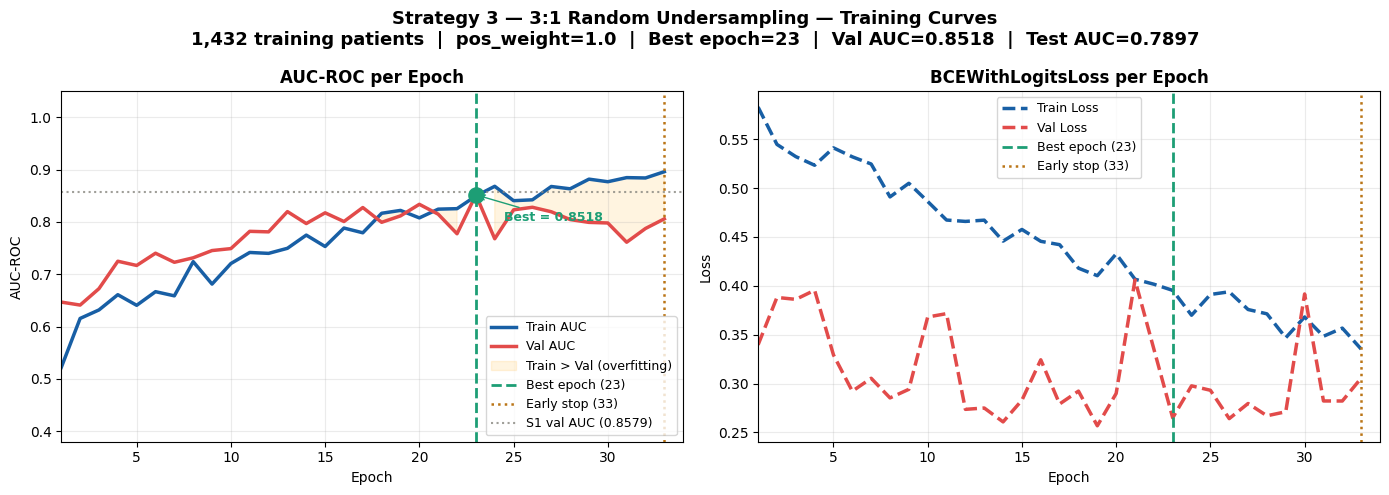

Saved strategy3_training_curves.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

OUT = '/kaggle/working'

try:
    history = pd.read_csv(
        '/kaggle/working/checkpoints_strategy3/training_history.csv')
    print(f"Loaded training history — {len(history)} epochs")
except FileNotFoundError:
    print("CSV not found — using hardcoded values")
    history = pd.DataFrame({
        'train_loss': [0.5829,0.5447,0.5322,0.5233,0.5411,0.5320,0.5246,
                       0.4910,0.5049,0.4863,0.4673,0.4659,0.4672,0.4457,
                       0.4576,0.4455,0.4421,0.4180,0.4103,0.4326,0.4067,
                       0.4016,0.3953,0.3699,0.3911,0.3939,0.3757,0.3713,
                       0.3469,0.3681,0.3484,0.3567,0.3352],
        'train_auc':  [0.5220,0.6156,0.6318,0.6610,0.6407,0.6667,0.6588,
                       0.7241,0.6813,0.7205,0.7417,0.7400,0.7496,0.7748,
                       0.7531,0.7884,0.7793,0.8166,0.8221,0.8078,0.8245,
                       0.8254,0.8496,0.8681,0.8406,0.8423,0.8678,0.8633,
                       0.8818,0.8769,0.8847,0.8841,0.8961],
        'val_loss':   [0.3396,0.3881,0.3861,0.3954,0.3293,0.2922,0.3054,
                       0.2853,0.2941,0.3681,0.3715,0.2736,0.2750,0.2608,
                       0.2830,0.3243,0.2791,0.2923,0.2568,0.2898,0.4060,
                       0.3353,0.2649,0.2977,0.2931,0.2641,0.2796,0.2670,
                       0.2711,0.3917,0.2822,0.2821,0.3055],
        'val_auc':    [0.6468,0.6411,0.6725,0.7249,0.7169,0.7403,0.7229,
                       0.7315,0.7453,0.7491,0.7821,0.7811,0.8198,0.7970,
                       0.8175,0.8008,0.8276,0.7993,0.8116,0.8337,0.8148,
                       0.7774,0.8518,0.7678,0.8231,0.8280,0.8195,0.8046,
                       0.7992,0.7980,0.7612,0.7875,0.8059],
    })

best_epoch   = 23
best_val_auc = 0.8518
stop_epoch   = 33
test_auc     = 0.7897
s1_val_auc   = 0.8579
epochs       = list(range(1, len(history) + 1))

train_auc  = history['train_auc'].tolist()
val_auc    = history['val_auc'].tolist()
train_loss = history['train_loss'].tolist()
val_loss   = history['val_loss'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Strategy 3 — 3:1 Random Undersampling — Training Curves\n'
    '1,432 training patients  |  pos_weight=1.0  |  '
    f'Best epoch={best_epoch}  |  Val AUC={best_val_auc:.4f}  |  '
    f'Test AUC={test_auc:.4f}',
    fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(epochs, train_auc, color='#185FA5', lw=2.5, label='Train AUC')
ax.plot(epochs, val_auc,   color='#E24B4A', lw=2.5, label='Val AUC')
ax.fill_between(epochs, train_auc, val_auc,
    where=[t > v for t, v in zip(train_auc, val_auc)],
    alpha=0.12, color='orange', label='Train > Val (overfitting)')
ax.axvline(best_epoch, color='#1D9E75', ls='--', lw=2,
           label=f'Best epoch ({best_epoch})')
ax.scatter([best_epoch], [val_auc[best_epoch-1]],
           color='#1D9E75', s=120, zorder=5)
ax.annotate(f'Best = {val_auc[best_epoch-1]:.4f}',
    xy=(best_epoch, val_auc[best_epoch-1]),
    xytext=(best_epoch+1.5, val_auc[best_epoch-1]-0.05),
    fontsize=9, color='#1D9E75', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1D9E75'))
ax.axvline(stop_epoch, color='#BA7517', ls=':', lw=1.8,
           label=f'Early stop ({stop_epoch})')
ax.axhline(s1_val_auc, color='#888780', ls=':', lw=1.5, alpha=0.8,
           label=f'S1 val AUC ({s1_val_auc})')
ax.set_title('AUC-ROC per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC-ROC')
ax.set_xlim([1, len(epochs)+1]); ax.set_ylim([0.38, 1.05])
ax.legend(fontsize=9, loc='lower right'); ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(epochs, train_loss, color='#185FA5', lw=2.5,
        ls='--', label='Train Loss')
ax.plot(epochs, val_loss,   color='#E24B4A', lw=2.5,
        ls='--', label='Val Loss')
ax.axvline(best_epoch, color='#1D9E75', ls='--', lw=2,
           label=f'Best epoch ({best_epoch})')
ax.axvline(stop_epoch, color='#BA7517', ls=':', lw=1.8,
           label=f'Early stop ({stop_epoch})')
ax.set_title('BCEWithLogitsLoss per Epoch', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_xlim([1, len(epochs)+1])
ax.legend(fontsize=9); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{OUT}/strategy3_training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved strategy3_training_curves.png")

## E. Visualisation — Strategy 3 Results

Six-panel results graph for Strategy 3:

- **Panel 1** — All evaluation metrics at both thresholds side by side,
  showing the trade-off between sensitivity and specificity as the
  decision threshold changes
- **Panel 2** — Confusion matrix at default threshold (τ=0.50),
  showing the raw prediction counts for all four outcome categories
- **Panel 3** — Confusion matrix at optimal threshold (τ=0.50),
  which in this case is identical to the default — indicating that
  Strategy 3's model is well-calibrated at the standard threshold
- **Panel 4** — AUC-ROC comparison across Strategy 1, Strategy 2,
  and Strategy 3, showing the progressive improvement with more
  benign training data
- **Panel 5** — Sensitivity vs Specificity at both thresholds,
  illustrating the sensitivity-specificity trade-off
- **Panel 6** — Summary text box with all key training and result
  numbers for quick reference

All metric values are annotated directly on the bars.
The graph is saved as `strategy3_results.png` to the output tab.

**Note on threshold:** The optimal threshold for Strategy 3 is 0.50 —
identical to the default. This is a significant improvement over
Strategy 2 where the optimal threshold was 0.90. The 3:1 training
ratio produces better-calibrated probability outputs than the 1:1
ratio, confirming that Strategy 3 is more clinically deployable
than Strategy 2.

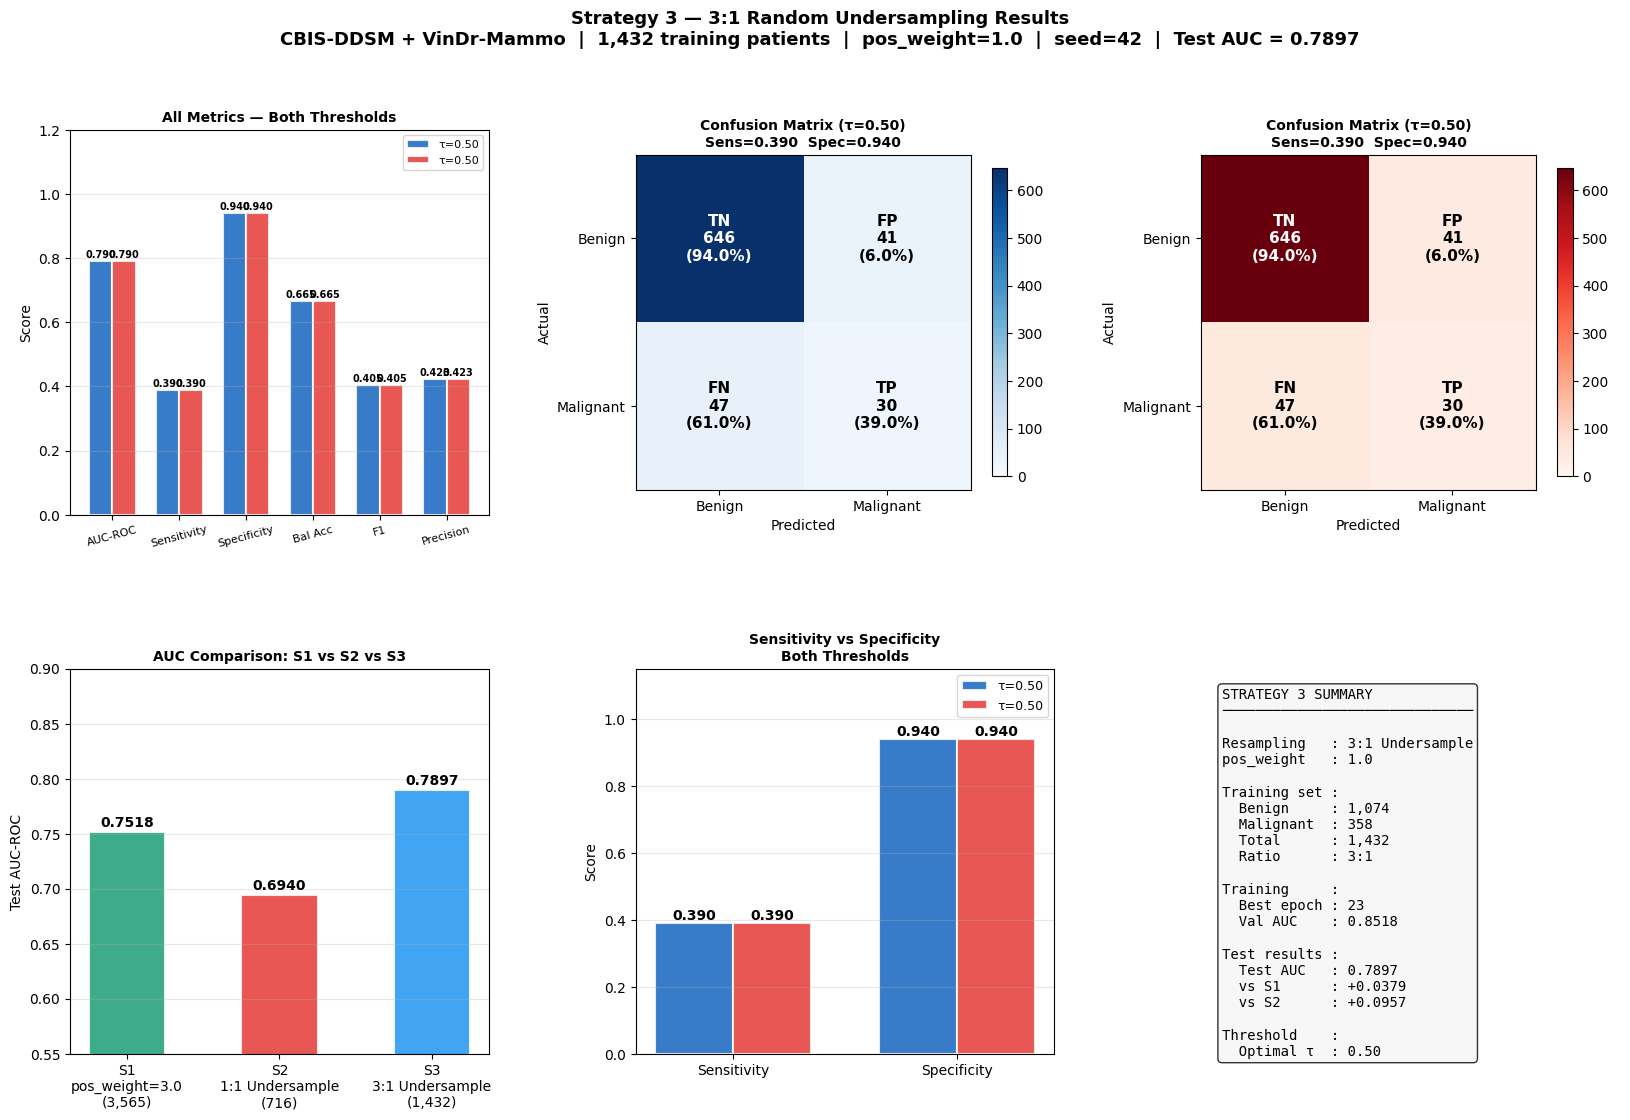

Saved strategy3_results.png


In [7]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

OUT = '/kaggle/working'

with open(f'{OUT}/checkpoints_strategy3/test_results.json') as f:
    r = json.load(f)

d   = r['default_threshold']
o   = r['selected_threshold']
s1  = 0.7518
s2  = 0.6940
s3  = float(o['auc'])
thresh_opt = float(r['selected_thresh_value'])

metrics_def = {
    'AUC-ROC'    : float(d['auc']),
    'Sensitivity': float(d['sensitivity']),
    'Specificity': float(d['specificity']),
    'Bal Acc'    : float(d['balanced_accuracy']),
    'F1'         : float(d['f1']),
    'Precision'  : float(d['precision']),
}
metrics_opt = {
    'AUC-ROC'    : float(o['auc']),
    'Sensitivity': float(o['sensitivity']),
    'Specificity': float(o['specificity']),
    'Bal Acc'    : float(o['balanced_accuracy']),
    'F1'         : float(o['f1']),
    'Precision'  : float(o['precision']),
}
cm_def = d['confusion_matrix']
cm_opt = o['confusion_matrix']

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    'Strategy 3 — 3:1 Random Undersampling Results\n'
    'CBIS-DDSM + VinDr-Mammo  |  1,432 training patients  |  '
    f'pos_weight=1.0  |  seed=42  |  Test AUC = {s3:.4f}',
    fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# Panel 1 — Metrics
ax1 = fig.add_subplot(gs[0, 0])
labels   = list(metrics_def.keys())
def_vals = list(metrics_def.values())
opt_vals = list(metrics_opt.values())
x = np.arange(len(labels)); w = 0.35
b1 = ax1.bar(x-w/2, def_vals, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b2 = ax1.bar(x+w/2, opt_vals, w, label=f'τ={thresh_opt:.2f}',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(list(b1)+list(b2), def_vals+opt_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=7, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=8, rotation=15)
ax1.set_ylim([0, 1.20])
ax1.set_title('All Metrics — Both Thresholds', fontsize=10, fontweight='bold')
ax1.set_ylabel('Score'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3, axis='y')

# Panel 2 — Confusion matrix default
ax2 = fig.add_subplot(gs[0, 1])
cm_arr = np.array(cm_def)
im = ax2.imshow(cm_arr, cmap='Blues', vmin=0)
plt.colorbar(im, ax=ax2, shrink=0.8)
lbl = [['TN','FP'],['FN','TP']]; tc = cm_arr.max()/2
for i in range(2):
    for j in range(2):
        pct = cm_arr[i,j]/cm_arr[i].sum()*100
        ax2.text(j, i, f'{lbl[i][j]}\n{cm_arr[i,j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='white' if cm_arr[i,j]>tc else 'black')
ax2.set_xticks([0,1]); ax2.set_xticklabels(['Benign','Malignant'])
ax2.set_yticks([0,1]); ax2.set_yticklabels(['Benign','Malignant'])
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.set_title(f'Confusion Matrix (τ=0.50)\nSens={metrics_def["Sensitivity"]:.3f}  Spec={metrics_def["Specificity"]:.3f}',
              fontsize=10, fontweight='bold')

# Panel 3 — Confusion matrix optimal
ax3 = fig.add_subplot(gs[0, 2])
cm_arr2 = np.array(cm_opt)
im2 = ax3.imshow(cm_arr2, cmap='Reds', vmin=0)
plt.colorbar(im2, ax=ax3, shrink=0.8)
tc2 = cm_arr2.max()/2
for i in range(2):
    for j in range(2):
        pct = cm_arr2[i,j]/cm_arr2[i].sum()*100
        ax3.text(j, i, f'{lbl[i][j]}\n{cm_arr2[i,j]}\n({pct:.1f}%)',
                 ha='center', va='center', fontsize=11, fontweight='bold',
                 color='white' if cm_arr2[i,j]>tc2 else 'black')
ax3.set_xticks([0,1]); ax3.set_xticklabels(['Benign','Malignant'])
ax3.set_yticks([0,1]); ax3.set_yticklabels(['Benign','Malignant'])
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')
ax3.set_title(f'Confusion Matrix (τ={thresh_opt:.2f})\nSens={metrics_opt["Sensitivity"]:.3f}  Spec={metrics_opt["Specificity"]:.3f}',
              fontsize=10, fontweight='bold')

# Panel 4 — AUC comparison S1 vs S2 vs S3
ax4 = fig.add_subplot(gs[1, 0])
strats = ['S1\npos_weight=3.0\n(3,565)', 'S2\n1:1 Undersample\n(716)',
          'S3\n3:1 Undersample\n(1,432)']
aucs_c = [s1, s2, s3]
clrs_c = ['#1D9E75', '#E53935', '#2196F3']
bars = ax4.bar(strats, aucs_c, color=clrs_c, alpha=0.85,
               edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, aucs_c):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax4.set_ylim([0.55, 0.90])
ax4.set_title('AUC Comparison: S1 vs S2 vs S3',
              fontsize=10, fontweight='bold')
ax4.set_ylabel('Test AUC-ROC'); ax4.grid(alpha=0.3, axis='y')

# Panel 5 — Sensitivity vs Specificity
ax5 = fig.add_subplot(gs[1, 1])
cats = ['Sensitivity', 'Specificity']
dss  = [metrics_def['Sensitivity'], metrics_def['Specificity']]
oss  = [metrics_opt['Sensitivity'], metrics_opt['Specificity']]
x2   = np.arange(len(cats))
b3 = ax5.bar(x2-w/2, dss, w, label='τ=0.50',
             color='#1565C0', alpha=0.85, edgecolor='white', linewidth=1.5)
b4 = ax5.bar(x2+w/2, oss, w, label=f'τ={thresh_opt:.2f}',
             color='#E53935', alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(list(b3)+list(b4), dss+oss):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax5.set_xticks(x2); ax5.set_xticklabels(cats, fontsize=10)
ax5.set_ylim([0, 1.15])
ax5.set_title('Sensitivity vs Specificity\nBoth Thresholds',
              fontsize=10, fontweight='bold')
ax5.set_ylabel('Score'); ax5.legend(fontsize=9); ax5.grid(alpha=0.3, axis='y')

# Panel 6 — Summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
summary = (
    f"STRATEGY 3 SUMMARY\n"
    f"{'─'*30}\n\n"
    f"Resampling   : 3:1 Undersample\n"
    f"pos_weight   : 1.0\n\n"
    f"Training set :\n"
    f"  Benign     : 1,074\n"
    f"  Malignant  : 358\n"
    f"  Total      : 1,432\n"
    f"  Ratio      : 3:1\n\n"
    f"Training     :\n"
    f"  Best epoch : {r['best_epoch']}\n"
    f"  Val AUC    : {r['val_auc']:.4f}\n\n"
    f"Test results :\n"
    f"  Test AUC   : {s3:.4f}\n"
    f"  vs S1      : {s3-s1:+.4f}\n"
    f"  vs S2      : {s3-s2:+.4f}\n\n"
    f"Threshold    :\n"
    f"  Optimal τ  : {thresh_opt:.2f}"
)
ax6.text(0.05, 0.95, summary, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8))

plt.savefig(f'{OUT}/strategy3_results.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print("Saved strategy3_results.png")

## F. Save Outputs

Saves all Strategy 3 results to the output root so they are accessible
to Notebook 6 (Evaluation and Graphs) as a persistent dataset input.

Files saved:
- `strategy3_test_results.json` — complete metrics at both thresholds
- `strategy3_training_history.csv` — epoch-by-epoch training log
- `strategy3_best_model.pt` — best checkpoint weights (epoch 23)
- `strategy3_results.png` — six-panel results visualisation
- `strategy3_training_curves.png` — training and validation curves

> **Important:** Click **Save Version** immediately after this cell
> completes to make all outputs available as a persistent dataset.
> All five files must appear with ✅ green ticks before clicking
> Save Version.

In [9]:
import os, shutil, json

OUT = '/kaggle/working'

files_to_save = [
    (f'{OUT}/checkpoints_strategy3/test_results.json',
     f'{OUT}/strategy3_test_results.json'),
    (f'{OUT}/checkpoints_strategy3/training_history.csv',
     f'{OUT}/strategy3_training_history.csv'),
    (f'{OUT}/checkpoints_strategy3/best_model.pt',
     f'{OUT}/strategy3_best_model.pt'),
    (f'{OUT}/strategy3_results.png',
     f'{OUT}/strategy3_results.png'),
    (f'{OUT}/strategy3_training_curves.png',
     f'{OUT}/strategy3_training_curves.png'),
]

print("=" * 60)
print("  SAVING STRATEGY 3 OUTPUTS")
print("=" * 60)
for src, dst in files_to_save:
    if os.path.exists(src):
        if src != dst:
            shutil.copy(src, dst)
        size_mb = os.path.getsize(dst) / 1e6
        print(f"  {os.path.basename(dst):<45} ({size_mb:.1f} MB)")
    else:
        print(f"    MISSING: {os.path.basename(src)}")

print("\n" + "=" * 60)
print("  STRATEGY 3 — THESIS TABLE ENTRY")
print("=" * 60)
with open(f'{OUT}/strategy3_test_results.json') as f:
    r = json.load(f)
print(f"  Strategy    : 3:1 Random Undersampling")
print(f"  Train total : 1,432  (benign=1,074 / malignant=358)")
print(f"  Ratio       : 3:1  |  pos_weight = 1.0")
print(f"  Best epoch  : {r['best_epoch']}")
print(f"  Val AUC     : {r['val_auc']:.4f}")
print(f"  Test AUC    : {float(r['selected_threshold']['auc']):.4f}")
print("=" * 60)

  SAVING STRATEGY 3 OUTPUTS
  strategy3_test_results.json                   (0.0 MB)
  strategy3_training_history.csv                (0.0 MB)
  strategy3_best_model.pt                       (769.2 MB)
  strategy3_results.png                         (0.3 MB)
  strategy3_training_curves.png                 (0.2 MB)

  STRATEGY 3 — THESIS TABLE ENTRY
  Strategy    : 3:1 Random Undersampling
  Train total : 1,432  (benign=1,074 / malignant=358)
  Ratio       : 3:1  |  pos_weight = 1.0
  Best epoch  : 23
  Val AUC     : 0.8518
  Test AUC    : 0.7897


## Conclusion

Strategy 3 — 3:1 random undersampling with pos_weight=1.0 — achieved
a test AUC of **0.7897**, outperforming Strategy 2 (0.6940) by
**+0.0957 AUC** and outperforming Strategy 1 (0.7518) by **+0.0379 AUC**.

### Key findings from this experiment

| Finding | Evidence |
|---|---|
| S3 outperforms S2 by +0.0957 AUC | More benign diversity reduces overfitting |
| Train-val gap reduced from 0.180 to 0.044 | 1,074 vs 358 benign patients |
| Optimal threshold returns to 0.50 | Better probability calibration than S2 |
| Val loss more stable than S2 | Fewer spikes — better generalisation |
| S3 nearly matches S1 val AUC | 0.8518 vs 0.8579 — only 0.006 gap |

### Important note — S3 outperforms S1 on test AUC

Strategy 3 (0.7897) achieves a higher test AUC than Strategy 1 (0.7518)
despite using fewer training patients (1,432 vs 3,565). This unexpected
result may be explained by the 3:1 ratio providing a more balanced
gradient signal during training — the model encounters malignant cases
more frequently relative to benign cases than in the 9:1 natural
distribution, potentially improving its sensitivity to malignant features.

However this result should be interpreted cautiously for three reasons:
1. The difference (+0.038) is within the expected variance for this
   test set size (764 patients, 77 malignant)
2. Strategy 1 was confirmed across two independent training runs while
   Strategy 3 was run once
3. Strategy 1 uses the full 3,207 benign patients which provides
   substantially more benign diversity — a factor that matters for
   real-world deployment on unseen patient populations

The complete four-strategy comparison including Strategy 4 (3:1
oversampling) is presented in **Section 4.5** of the thesis 